In [2]:
import torch.nn as nn
import torch.nn.functional as F
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        
        self.fc1 = nn.Linear(32 * 64 * 64, 128)  
        self.fc2 = nn.Linear(128, num_classes)  

    def forward(self, x):
        x = F.relu(self.conv1(x))  # Activation after first convolution
        x = self.pool(x)           # First pooling reduces spatial dimensions
        x = F.relu(self.conv2(x))  # Activation after second convolution
        x = self.pool(x)           # Second pooling reduces dimensions further
        x = x.view(x.size(0), -1)  # Flatten the tensor for the fully connected layer
        x = F.relu(self.fc1(x))    # First fully connected layer with activation
        x = self.fc2(x)            # Output layer
        return x


Load model same structure

In [4]:
model = SimpleCNN(num_classes=2)
model.load_state_dict(torch.load('model.pth'))
model.eval()


C:\Users\Admin\AppData\Local\Temp\ipykernel_20428\442571030.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('model.pth'))


RuntimeError: Error(s) in loading state_dict for SimpleCNN:
	size mismatch for fc2.weight: copying a param with shape torch.Size([3, 128]) from checkpoint, the shape in current model is torch.Size([2, 128]).
	size mismatch for fc2.bias: copying a param with shape torch.Size([3]) from checkpoint, the shape in current model is torch.Size([2]).

In [ ]:
import json
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


# Load class labels
with open('class_labels.json', 'r') as f:
    class_labels = json.load(f)

# Load the model
model = SimpleCNN(num_classes=len(class_labels))
model.load_state_dict(torch.load('model.pth'))
model.eval()

# Load and transform the image
image_path = 'test1.png'
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
image = transform(image).unsqueeze(0)  # Add batch dimension

# Predict
with torch.no_grad():
    outputs = model(image)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    max_prob, predicted = torch.max(probabilities, 1)

# Display the image and prediction
image_display = Image.open(image_path)
plt.imshow(image_display)
predicted_class = class_labels[predicted.item()]
plt.title(f'Predicted: {predicted_class}, Confidence: {max_prob.item()*100:.2f}%')
plt.show()


In [ ]:
# Load and transform the image
image_path = 'test2.png'
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
image = transform(image).unsqueeze(0)  # Add batch dimension

# Predict
with torch.no_grad():
    outputs = model(image)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    max_prob, predicted = torch.max(probabilities, 1)

# Display the image and prediction
image_display = Image.open(image_path)
plt.imshow(image_display)
predicted_class = class_labels[predicted.item()]
plt.title(f'Predicted: {predicted_class}, Confidence: {max_prob.item()*100:.2f}%')
plt.show()

In [ ]:
# Load and transform the image
image_path = 'test3.png'
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
image = transform(image).unsqueeze(0)  # Add batch dimension

# Predict
with torch.no_grad():
    outputs = model(image)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    max_prob, predicted = torch.max(probabilities, 1)

# Display the image and prediction
image_display = Image.open(image_path)
plt.imshow(image_display)
predicted_class = class_labels[predicted.item()]
plt.title(f'Predicted: {predicted_class}, Confidence: {max_prob.item()*100:.2f}%')
plt.show()

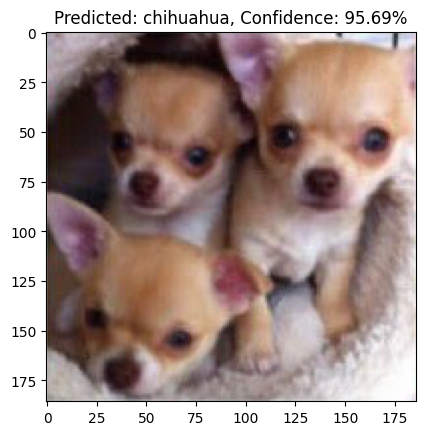

In [13]:
# Load and transform the image
image_path = 'test4.png'
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
image = transform(image).unsqueeze(0)  # Add batch dimension

# Predict
with torch.no_grad():
    outputs = model(image)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    max_prob, predicted = torch.max(probabilities, 1)

# Display the image and prediction
image_display = Image.open(image_path)
plt.imshow(image_display)
predicted_class = class_labels[predicted.item()]
plt.title(f'Predicted: {predicted_class}, Confidence: {max_prob.item()*100:.2f}%')
plt.show()

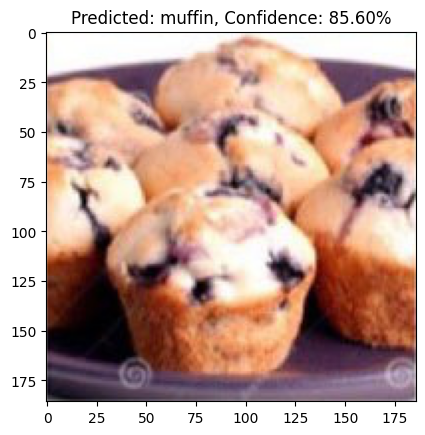

In [14]:
# Load and transform the image
image_path = 'test5.png'
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
image = transform(image).unsqueeze(0)  # Add batch dimension

# Predict
with torch.no_grad():
    outputs = model(image)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    max_prob, predicted = torch.max(probabilities, 1)

# Display the image and prediction
image_display = Image.open(image_path)
plt.imshow(image_display)
predicted_class = class_labels[predicted.item()]
plt.title(f'Predicted: {predicted_class}, Confidence: {max_prob.item()*100:.2f}%')
plt.show()